In [2]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()

model.fit(train_input, train_target)
model.predict([[50]])

# perch_length는 train 샘플 데이터로, fit함수는 2차원 배열로 받아야 함.
# target인 weight는 1차원 배열이어도 무방함.

[19.6] 85.0


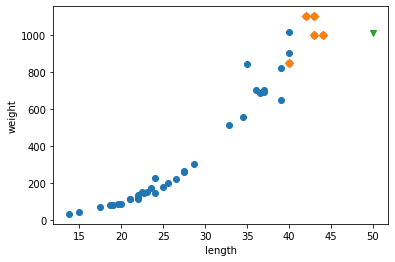

In [3]:
# 훈련세트와 50cm 농어, 그리고 이 농어의 최근접 이웃을 산점도에 표시해본다.

import matplotlib.pyplot as plt

# 50cm길이 농어의 이웃들을 구한다.
distances, indexes = model.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(50, model.predict([[50]]), marker='v')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [7]:
# 위 산점도를 보면 길이가 50인 농어의 이웃은 평균적으로 얼마의 무게일까?

print(np.mean(train_target[indexes]))
# 1010이라고 한다.
 
# 이 농어들의 길이와 무게들은?
for l, w in zip(train_input[indexes], train_target[indexes]):
  print(l, w)

1010.0
[[44.]
 [43.]
 [43.]
 [42.]
 [40.]] [1000. 1100. 1000. 1100.  850.]


In [ ]:
# 즉, 이 모델은 길이가 100cm인 농어도, 1000 cm인 농어도 저 값과 동일하게 예측을 한다.
# 이런식이면 농어길이가 길어져도 더이상 모델의 예측 회귀값이 바뀌지 않는다!

# K-최근접 이웃 회귀말고 다른 알고리즘은 없을까? --> 선형 회귀.
# 선형 회귀는 특성이 하나일 때 회귀모델을 학습할 수 있는 알고리즘이다.

# 선형 회귀

```
from sklearn.linear_model import LinearRegression
```
K-최근접 이웃 회귀는 거리가 가까운 샘플들의 평균값을 바탕으로 회귀값을 추정하지만, 이 경우 특성이 하나일 때 제대로 회귀값을 내지 못하는 경우가 있다. 이 때 학습 데이터의 특성과 타깃간 선형 상관관계를 학습하여 테스트 데이터에 대한 회귀값을 추정할 때 선형 회귀가 사용될 수 있다. (단, 학습 데이터의 특성이 1개일 경우)

In [11]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(train_input, train_target)
predicted_weight = linear_model.predict([[50]])

길이가 50인 농어의 무게를 비교적 합리적으로 회귀한 것으로 보인다.
이를 시각화 해보자.

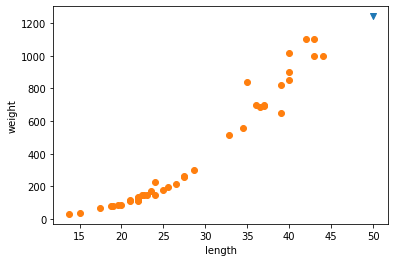

In [12]:
plt.scatter(50, predicted_weight[0], marker='v')
plt.scatter(train_input, train_target)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

y = ax + b 처럼 선형회귀는 coefficient(=weight, 가중치)와 intercept_ 값을 갖는다.

LinearRegression 클래스의 객체는 coef_ 와 intercept_ 속성을 갖는다.

> linear_model.coef_

> linear_model.intercept_

In [13]:
print("선형 회귀모델의 가중치: ", linear_model.coef_, "선형 회귀모델의 절편: ", linear_model.intercept_)

선형 회귀모델의 가중치:  [39.01714496] 선형 회귀모델의 절편:  -709.0186449535477


*   선형 회귀모델의 coef_와 intercept_ 를 머신러닝 알고리즘이 찾은 값이라는 의미로 **모델 파라미터** 라고 부른다. 이 책에서 사용하는 많은 머신러닝 알고리즘의 훈련 과정은 최적의 모델 파라미터를 찾는 것과 같다. 이를 모델 기반 학습 이라고 부른다. 
*   앞서 사용한 K-최근접 이웃에는 모델 파라미터가 없다. 훈련 세트를 저장하는 것이 훈련의 전부였고, 이를 사례 기반 학습이라고 한다.

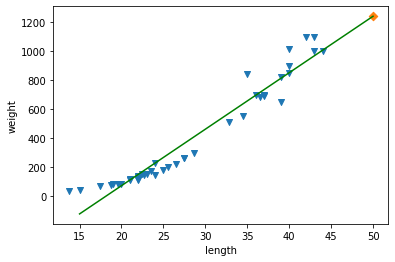

In [18]:
# 이제 농어의 길이 15에서 50까지 직선으로 그려보자.
# 이 직선을 그리려면 앞서 구한 기울기와 절편을 사용하여 두 점을 이으면 된다.
# 훈련세트의 산점도와 함께 그려보자.

# 15에서 50까지 1차 방정식 그래프 그린다.
plt.plot([15, 50], [15*linear_model.coef_+linear_model.intercept_, 50*linear_model.coef_+linear_model.intercept_], color='g')

# 50cm 농어 데이터와 학습 데이터
plt.scatter(train_input, train_target, marker='v')
plt.scatter(50, linear_model.predict([[50]]), marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [19]:
# 이제 이 모델의 결정계수 R^2를 계산해보자.

print(linear_model.score(train_input, train_target))
print(linear_model.score(test_input, test_target))

0.9398463339976039
0.8247503123313558


이 모델의 학습 데이터 성능이 테스트 데이터 성능보다는 좋지만, 오버피팅이라고도 할 수 없다. 성능이 93이면 그리 좋지 않기 때문이다. 따라서, 이 모델은 언더피팅 되었다고 볼 수 있다. 어떻게 개선할 수 있을까??

# 다항 회귀

지금까지는 선형회귀가 최적의 직선을 찾았다면, 위 녹색직선이 길이가 더 줄어들면 무게가 음수가 되는 비현실적인 모델이 아닌, 살짝 곡선인 회귀모델이 더욱 현실적이다.

즉, $$무게 = a*길이^2 + b*길이 + c$$

같은 2차 방정식 형태같은 모델이 되어야 한다.
농어의 길이 제곱을 학습 데이터에 추가하여보자.

In [20]:
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

print(train_poly.shape)
print(test_poly.shape)

(42, 2)
(14, 2)


In [22]:
# 이제 (길이제곱, 길이)의 2차원 학습 데이터/테스트 데이터로 선형 회귀모델을 다시 훈련해보자.

linear_model = LinearRegression()
linear_model.fit(train_poly, train_target)
#linear_model.score(test_poly, test_target)
print(linear_model.predict([[50**2, 50]]))

[1573.98423528]


In [23]:
# 이 때 coef와 intercep 값은 ???

print(linear_model.coef_)
print(linear_model.intercept_)

[  1.01433211 -21.55792498]
116.05021078278276


즉 위 선형회귀모델은 

$$ 무게 = 1.01433211 * 길이^2 -21.55792498 * 길이 + 116.05021078278276 $$

라는 그래프를 학습했다.

**이런 방정식을 다항식(polynomial)이라고 부르며, 다항식을 사용한 선형 회귀를 다항 회귀 (polynomial regression)** 이라고 한다.

그럼 이 2차 방정식의 계수와 절편을 알았으니, 이전과 동일하게 훈련 세트의 산점도에 그래프로 그려보자. 짧은 직선을 이어서 그리면 마치 곡선처럼 표현할 수 있다. 여기서는 1씩 짧게 끊어서 그려본다.

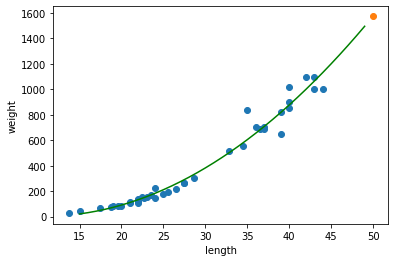

In [26]:
point = np.arange(15, 50)

# 훈련 세트의 산점도
plt.scatter(train_input, train_target)

# 15에서 49까지 2차 방정식 그래프 그리기
plt.plot(point, 1.01433211*point**2-21.55792498*point+116.05021078278276, color='g')

# 50cm 농어 데이터
plt.scatter(50, linear_model.predict([[50**2, 50]]))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

# 2차 방정식의 그래프를 학습한 것은 비선형 아닌가?

위 회귀 모델은 맨 위 1차원 그래프를 학습한 것과 다르게, 길이^2이 들어가는 곡선 형태의 2차원 그래프를 학습하였다.

그러면, 이 회귀 모델은 선형 회귀가 아니라 비선형 회귀모델이 아닌가??

답은 아니다.

왜냐하면 길이^2는 '왕길이'처럼 다른 변수로 치환할 수 있으며, 이 경우 무게는 왕길이와 길이의 선형 관계로 표현할 수 있기 때문에, 여전히 선형 회귀 모델이다.

In [28]:
# 마지막으로 위 선형 회귀모델의 성능을 평가해보자 (R^2)

print(linear_model.score(train_poly, train_target))
print(linear_model.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


이전 1차원 그래프 모델보다는 성능이 개선되었지만, 테스트 데이터의 성능이 약간 더 좋은걸 봐서는 언더피팅인 것 같다. 모델을 조금 더 복잡하게 구성해야 할 것 같다.

# 키워드로 끝내는 핵심 포인트

> 선형 회귀

특성과 타겟 사이의 관계를 잘 나타내는 선형 방정식을 찾는다. 특성이 하나면 직선 방정식이 된다. 선형회귀가 찾은 특성과 타겟 사이의 관계는 선형 방정식의 계수 또는 가중치에 저장된다. (가중치는 방정식의 기울기와 절편 모두를 의미하는 경우가 많다.)

> 모델 파라미터

선형 회귀가 찾은 가중치처럼 머신러닝 모델이 특성에서 학습한 파라미터를 말한다.

> 다항 회귀

다항식을 사용하여 특성과 타겟 사이의 관계를 나타낸다. 이 함수는 비선형일 수 있지만, 선형 회귀로 표현할 수도 있다.

# 핵심 패키지와 함수

```
from sklearn.linear_model import LinearRegression
```

fit_intercept 매개변수를 False로 지정하면 절편을 학습하지 않는다. 학습된 모델의 coef_ 속성은 특성에 대한 계수를 포함한 배열이다. 즉, 이 배열의 크기는 특성의 개수와 같다. intercept_에는 절편이 저장된다.
길이^2, 길이를 갖고 학습한 다항회귀 모델에서는 두 개의 특성이 학습에 사용되어 두 개의 모델 파라미터(가중치)가 학습되었다. (절편 제외하고)